In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Cleaning

In [3]:
df = pd.read_csv('/content/taxi_trip_pricing.csv')

In [4]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [5]:
df.shape

(1000, 11)

In [6]:
if df.duplicated().sum() == 0:
  print("No Duplicate Values")
else:
  print("Duplicate Values Found")

No Duplicate Values


In [7]:
df.isna().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [8]:
df.sample(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
25,39.47,Afternoon,Weekday,1.0,Low,Clear,NaN,NaN,0.35,7.59,83.6965
413,29.10,Morning,Weekday,4.0,High,Clear,3.26,0.82,0.12,29.80,30.6980
390,49.53,Morning,Weekday,2.0,Medium,Clear,4.16,1.19,0.16,36.33,68.9135
210,27.89,NaN,Weekend,1.0,Low,Clear,2.51,0.65,0.11,97.69,31.3844
428,NaN,Afternoon,Weekday,NaN,Medium,Rain,3.84,1.55,0.41,19.20,39.9065
777,36.39,Afternoon,Weekday,2.0,Low,NaN,3.09,0.64,0.27,67.24,44.5344
154,49.30,Afternoon,Weekday,2.0,Low,Clear,2.38,0.86,0.40,47.72,63.8660
190,5.56,Morning,Weekday,4.0,High,Clear,NaN,1.69,0.13,54.22,19.1450
810,49.26,Afternoon,Weekday,4.0,Low,Clear,3.09,1.95,0.29,35.46,109.4304
337,35.48,Afternoon,Weekday,3.0,Low,Clear,3.23,1.43,0.38,72.19,81.3986


In [9]:
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [10]:
# Replacing the null values by mean
mean_TDK = round(df['Trip_Distance_km'].mean(),2)
print(mean_TDK)
df['Trip_Distance_km']= df['Trip_Distance_km'].fillna(mean_TDK)

27.07


In [11]:
df.isna().sum()

,0
Trip_Distance_km,0
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [12]:
# Replacing the nan value by mode becasue it's a categorical column
mode_value = df['Time_of_Day'].mode()[0]
print(mode_value)
df['Time_of_Day'] = df['Time_of_Day'].fillna(mode_value)
df['Time_of_Day'].unique()

Afternoon


array(['Morning', 'Afternoon', 'Evening', 'Night'], dtype=object)

In [13]:
# Filling the values by mode it's categorical column
mode_of_Day_week = df['Day_of_Week'].mode()[0]
print(mode_of_Day_week)
df['Day_of_Week'] = df['Day_of_Week'].fillna(mode_of_Day_week)
df['Day_of_Week'].unique()
df['Day_of_Week'].isna().sum()

Weekday


np.int64(0)

In [14]:
# Passanger Count
df['Passenger_Count'].unique() # Categorical column -->> MODE
df['Passenger_Count'] = df['Passenger_Count'].fillna(df['Passenger_Count'].mode()[0])
df['Passenger_Count'].unique()


array([3., 1., 4., 2.])

In [15]:
# Traffic conditions have 50 Null values and I replace them with the mode
df['Traffic_Conditions'].unique()
df['Traffic_Conditions'] = df['Traffic_Conditions'].fillna(df['Traffic_Conditions'].mode()[0])
df['Traffic_Conditions'].unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [16]:
uniq = df['Weather'].unique()
print(uniq)
df['Weather'].isna().sum()

#Mode
W_mode = df['Weather'].mode()[0]
print(W_mode)

# Filling the null value
df['Weather'] = df['Weather'].fillna(W_mode)
df['Weather'].unique()


['Clear' nan 'Rain' 'Snow']
Clear


array(['Clear', 'Rain', 'Snow'], dtype=object)

In [17]:
# Base Fare it is continous variable so for filling these values we will caluculate it's mean
mean_Base_Fare = round(df['Base_Fare'].mean(),2)
print(mean_Base_Fare)

# Filling with it's mean value
df['Base_Fare'] = df['Base_Fare'].fillna(mean_Base_Fare)
if df['Base_Fare'].isna().sum() == 0:
  print("No Null Values")
else:
  print("Null Values Found")

3.5
No Null Values


In [18]:
# Rate of Per_Km is a continous number so we will replace this with mean

mean_of_per_km = (round(df['Per_Km_Rate'].mean(),2))

#Filling with mean
df['Per_Km_Rate']= df['Per_Km_Rate'].fillna(mean_of_per_km)

In [19]:
# Per_Minute_Rate is a also a continous varibale so we will replace this with mean too.
m_of_PerMinute = round(df['Trip_Duration_Minutes'].mean(),2)

#Replacing with mean value
df['Per_Minute_Rate']= df['Per_Minute_Rate'].fillna(m_of_PerMinute)

# checking
if df['Per_Minute_Rate'].isna().sum() == 0:
  print("No Null Values")
else:
  print("Null Values Found")


No Null Values


In [20]:
# This is a regression number so we will replace the nan values with mean
Mean_TDM = round(df['Trip_Duration_Minutes'].mean(),2)
df['Trip_Duration_Minutes'] = df['Trip_Duration_Minutes'].fillna(Mean_TDM)

In [21]:
Trip_Price_Mean = round(df['Trip_Price'].mean(),2)
df['Trip_Price']= df['Trip_Price'].fillna(Trip_Price_Mean)
if df['Trip_Price'].isna().sum() == 0:
  print("No Null Values")
else:
  print("Null Values Found")

No Null Values


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   object 
 2   Day_of_Week            1000 non-null   object 
 3   Passenger_Count        1000 non-null   float64
 4   Traffic_Conditions     1000 non-null   object 
 5   Weather                1000 non-null   object 
 6   Base_Fare              1000 non-null   float64
 7   Per_Km_Rate            1000 non-null   float64
 8   Per_Minute_Rate        1000 non-null   float64
 9   Trip_Duration_Minutes  1000 non-null   float64
 10  Trip_Price             1000 non-null   float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [23]:
# 1. Label Encoding for Ordinal Columns
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2}
time_map = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3}

df['Traffic_Conditions'] = df['Traffic_Conditions'].map(traffic_map)
df['Time_of_Day'] = df['Time_of_Day'].map(time_map)

# 2. One-Hot Encoding for nominal Columns
df = pd.get_dummies(df, columns=['Day_of_Week', 'Weather'], drop_first=True)

In [24]:
df.sample(5)

,Trip_Distance_km,Time_of_Day,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Day_of_Week_Weekend,Weather_Rain,Weather_Snow
351,42.970000,1,4.0,0,4.88,1.90,0.38,59.08,108.97340,True,False,False
267,116.196064,1,4.0,1,2.20,0.85,0.25,19.63,206.69957,True,False,False
99,6.290000,1,3.0,0,4.15,1.37,0.21,80.37,29.64500,False,False,False
550,26.490000,3,1.0,2,3.54,1.82,0.15,99.20,66.63180,False,False,False
191,27.070000,1,2.0,1,2.47,0.83,0.45,80.70,76.10180,True,False,False


In [25]:
df = df.astype({'Day_of_Week_Weekend': int, 'Weather_Rain': int, 'Weather_Snow': int})

In [26]:
df.tail(5)

,Trip_Distance_km,Time_of_Day,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Day_of_Week_Weekend,Weather_Rain,Weather_Snow
995,5.49,1,4.0,1,2.39,0.62,0.49,58.39,34.4049,1,0,0
996,45.95,3,4.0,1,3.12,0.61,62.12,61.96,62.1295,0,0,0
997,7.70,0,3.0,0,2.08,1.78,62.12,54.18,33.1236,0,1,0
998,47.56,0,1.0,0,2.67,0.82,0.17,114.94,61.2090,0,0,0
999,22.85,0,3.0,1,4.34,1.23,0.23,29.69,45.4437,1,0,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   int64  
 2   Passenger_Count        1000 non-null   float64
 3   Traffic_Conditions     1000 non-null   int64  
 4   Base_Fare              1000 non-null   float64
 5   Per_Km_Rate            1000 non-null   float64
 6   Per_Minute_Rate        1000 non-null   float64
 7   Trip_Duration_Minutes  1000 non-null   float64
 8   Trip_Price             1000 non-null   float64
 9   Day_of_Week_Weekend    1000 non-null   int64  
 10  Weather_Rain           1000 non-null   int64  
 11  Weather_Snow           1000 non-null   int64  
dtypes: float64(7), int64(5)
memory usage: 93.9 KB


## EDA

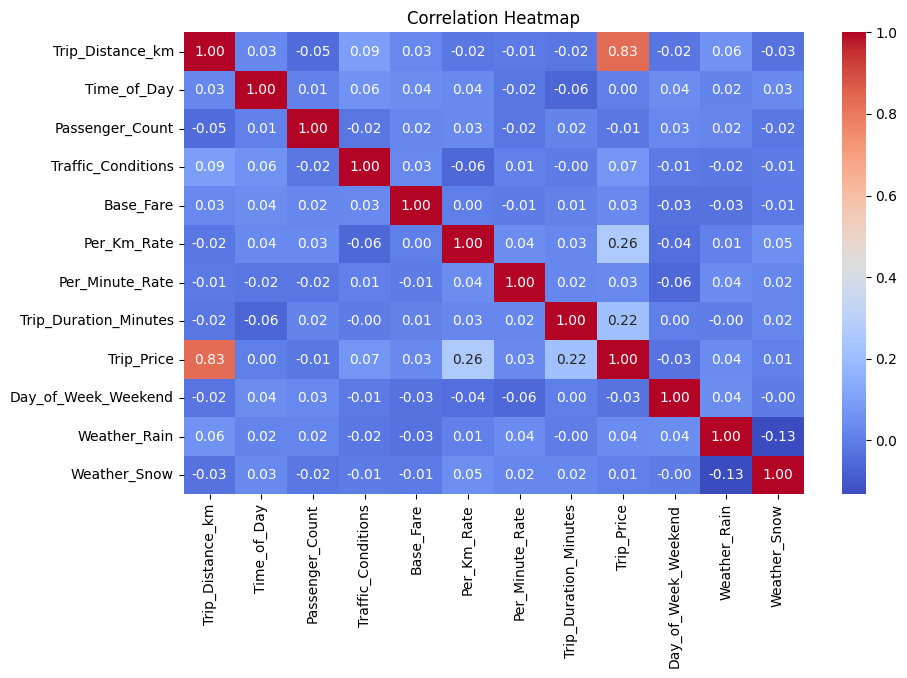

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot= True, cmap='coolwarm', fmt= ".2f")
plt.title("Correlation Heatmap")
plt.show()

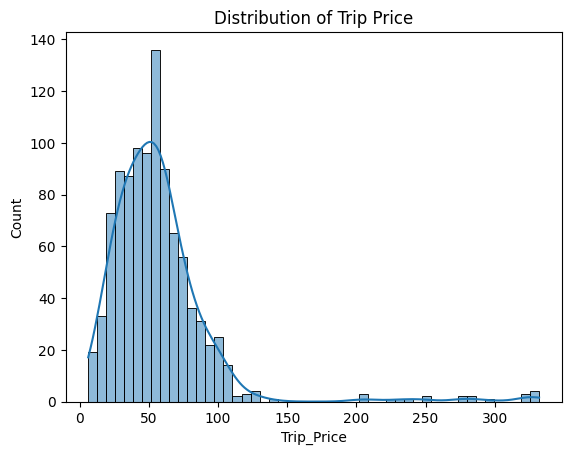

In [29]:
# Check the Distribution of Target Variable
sns.histplot(df['Trip_Price'], kde=True)
plt.title('Distribution of Trip Price')
plt.show()

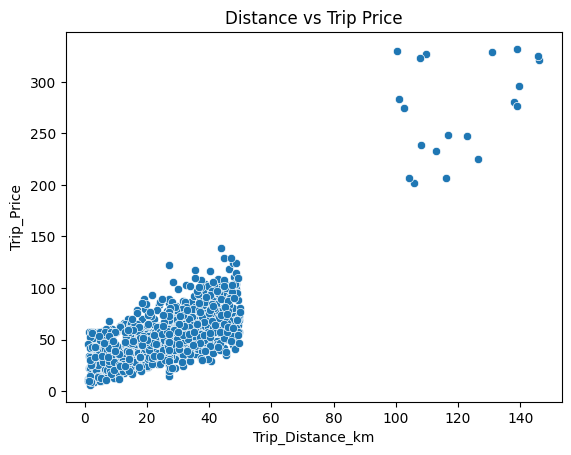

In [30]:
# Analyzing the Relationship between Distance and price
sns.scatterplot(x='Trip_Distance_km', y='Trip_Price', data=df)
plt.title('Distance vs Trip Price')
plt.show()

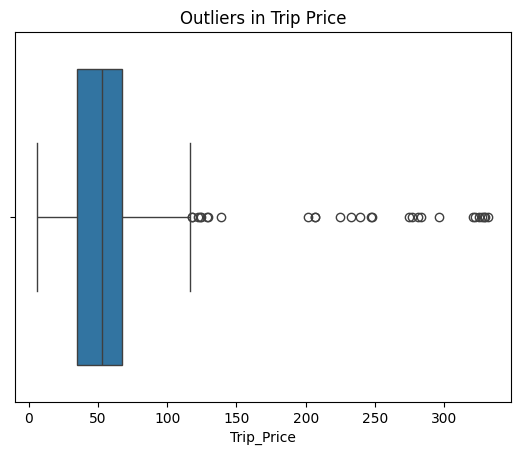

In [31]:
# checking the ouliers
sns.boxplot(x=df['Trip_Price'])
plt.title('Outliers in Trip Price')
plt.show()

<Axes: xlabel='Trip_Distance_km', ylabel='Trip_Price'>

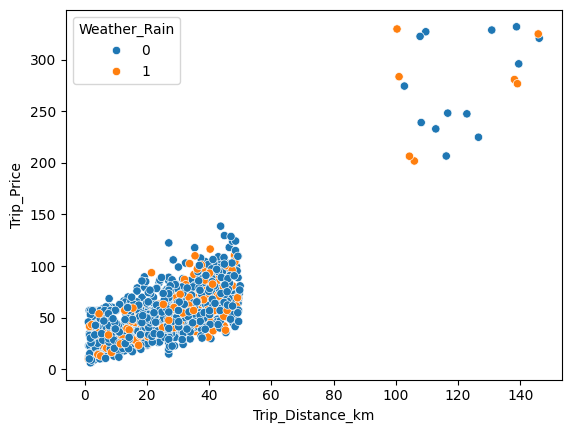

In [32]:
# This shows you how the distance-price relationship changes depending on the weather
sns.scatterplot(x='Trip_Distance_km', y='Trip_Price', hue='Weather_Rain', data=df)

## Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler
X = df.drop('Trip_Price', axis=1)
y = df['Trip_Price']

In [34]:
# Select only the columns that actually need to scaling (numeric,non-binary)
cols_to_scale = ['Trip_Distance_km', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate',
                 'Trip_Duration_Minutes']
scaler = StandardScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

In [35]:
X.head()

,Trip_Distance_km,Time_of_Day,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Day_of_Week_Weekend,Weather_Rain,Weather_Snow
0,-0.398148,0,3.0,0,0.067431,-1.034480,-0.227398,-0.264918,0,0,0
1,1.058192,1,1.0,2,-0.003350,-1.464369,-0.219235,-0.687919,0,0,0
2,0.505360,2,1.0,2,-0.947100,-0.055288,-0.240013,-0.793271,1,0,0
3,0.168092,2,4.0,0,-0.026944,-1.727079,-0.240013,1.746017,0,0,0
4,-0.000027,2,3.0,2,-0.675772,-1.440486,-0.227398,-1.260329,0,0,0


## Model Training

In [36]:
from sklearn.model_selection import train_test_split

# split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# check the shapes to confirm the split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (800, 11)
X_test shape: (200, 11)


## LinearRegression Algo

In [37]:
 from sklearn.linear_model import LinearRegression
 from sklearn.metrics import mean_absolute_error, r2_score

In [38]:
model = LinearRegression()

In [39]:
model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_test)

In [41]:
# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2_score(y_test, y_pred)}")

Mean Absolute Error: 12.346955447819948
R-squared: 0.6972216369525965


In [42]:
model.coef_

array([34.36398447, -0.70523347,  0.19368085, -0.38101678,  0.27499892,
       10.55787561,  1.42495237,  8.93936906,  0.50436491, -1.45820112,
        2.86178885])

In [43]:
model.intercept_

np.float64(57.19167507320114)

*The observed vs. Predicted plot*

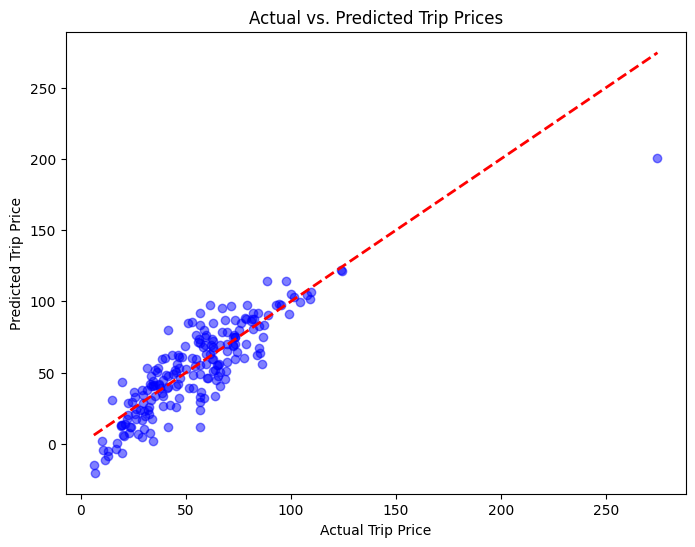

In [44]:
# Plotting Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # The ideal line
plt.xlabel('Actual Trip Price')
plt.ylabel('Predicted Trip Price')
plt.title('Actual vs. Predicted Trip Prices')
plt.show()

*The Distance vs. Price Regressioon plot*

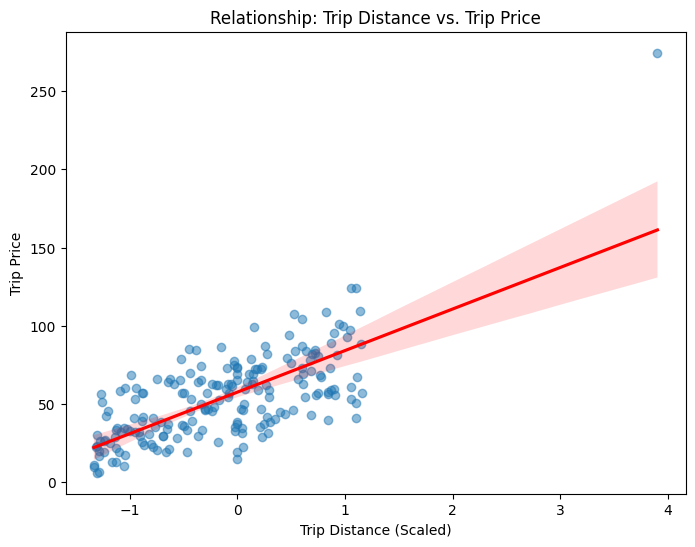

In [45]:
# Create a regression plot for the most important feature
plt.figure(figsize=(8, 6))
sns.regplot(x=X_test['Trip_Distance_km'], y=y_test, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship: Trip Distance vs. Trip Price')
plt.xlabel('Trip Distance (Scaled)')
plt.ylabel('Trip Price')
plt.show()

## RandomForestRegressor Algo

In [46]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [47]:
# 1. Predict on test data
rf_pred = rf_model.predict(X_test)

# 2. Evaluate performance
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE: {rf_mae}")
print(f"Random Forest R-squared: {rf_r2}")

Random Forest MAE: 5.817611174775185
Random Forest R-squared: 0.9186090284864211


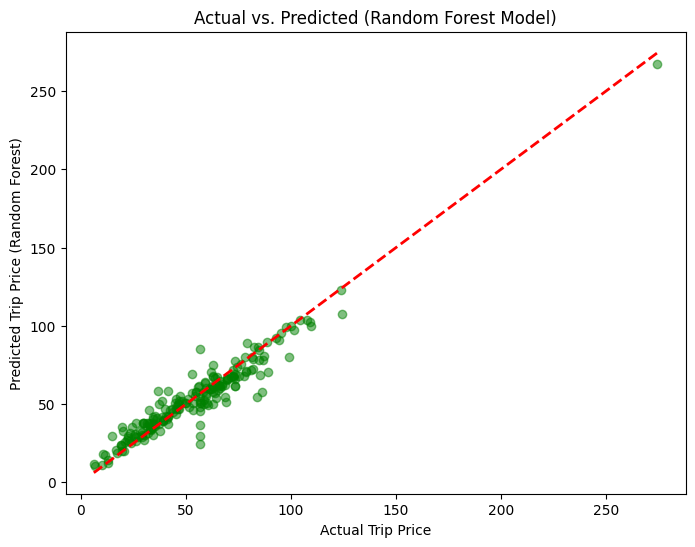

In [48]:
# Plotting Actual vs Predicted for Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, color='green') # Green for RF
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Trip Price')
plt.ylabel('Predicted Trip Price (Random Forest)')
plt.title('Actual vs. Predicted (Random Forest Model)')
plt.show()

In [49]:
import joblib

# Save the Random Forest model
joblib.dump(rf_model, 'taxi_price_model.pkl')

# Save the scaler (Crucial: You must scale user input exactly like training data!)
joblib.dump(scaler, 'taxi_scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
